# Experiment 05 – Bootstrap and Permutation Resampling

## Aim

To implement bootstrap and permutation resampling techniques on the Pima Indians Diabetes Dataset for estimating confidence intervals and analyzing statistical differences between groups.

## Objectives

1. To apply bootstrap and permutation resampling techniques to estimate sampling distributions and confidence intervals.
2. To interpret resampling results to support statistical decision making.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

In [2]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("diabetes.csv")
print("Dataset loaded successfully.")
display(df.head())

Saving diabetes.csv to diabetes.csv
Dataset loaded successfully.


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [3]:
print("Dataset Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (768, 9)

Missing Values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


## Bootstrap Resampling

In [4]:
glucose = df["Glucose"].dropna().to_numpy()
n_bootstrap = 10000
rng = np.random.default_rng(42)
bootstrap_means = np.empty(n_bootstrap)
for i in range(n_bootstrap):
    bootstrap_sample = rng.choice(
        glucose,
        size=len(glucose),
        replace=True
    )
    bootstrap_means[i] = bootstrap_sample.mean()
print("Number of bootstrap samples:", n_bootstrap)
print(f"Original sample mean: {glucose.mean():.2f}")
print(f"Bootstrap mean: {bootstrap_means.mean():.2f}")

Number of bootstrap samples: 10000
Original sample mean: 121.68
Bootstrap mean: 121.69


## Bootstrap Confidence Interval

In [5]:
lower_ci = np.percentile(bootstrap_means, 2.5)
upper_ci = np.percentile(bootstrap_means, 97.5)
print(f"95% Bootstrap Confidence Interval:")
print(f"Lower Bound: {lower_ci:.2f}")
print(f"Upper Bound: {upper_ci:.2f}")

95% Bootstrap Confidence Interval:
Lower Bound: 119.54
Upper Bound: 123.87


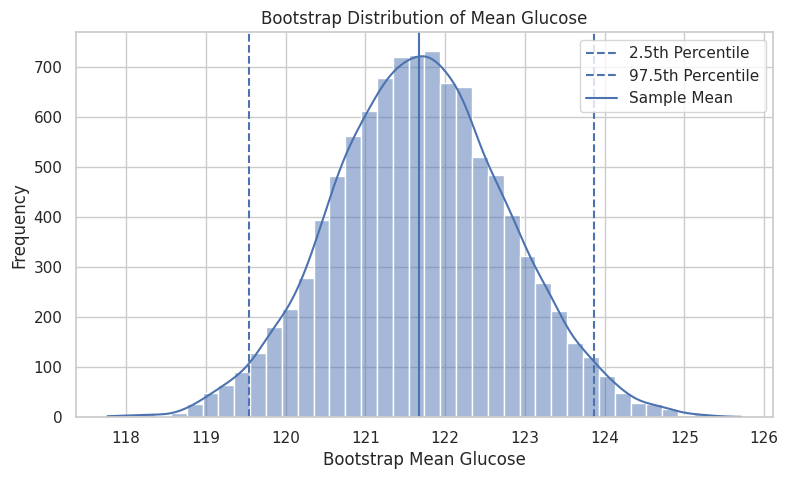

In [6]:
plt.figure(figsize=(9, 5))
sns.histplot(
    bootstrap_means,
    bins=40,
    kde=True
)
plt.axvline(
    lower_ci,
    linestyle="--",
    label="2.5th Percentile"
)
plt.axvline(
    upper_ci,
    linestyle="--",
    label="97.5th Percentile"
)
plt.axvline(
    glucose.mean(),
    linestyle="-",
    label="Sample Mean"
)
plt.title("Bootstrap Distribution of Mean Glucose")
plt.xlabel("Bootstrap Mean Glucose")
plt.ylabel("Frequency")
plt.legend()
plt.show()

## Permutation Test

In [7]:
glucose_diabetic = df[df["Outcome"] == 1]["Glucose"].to_numpy()
glucose_non_diabetic = df[df["Outcome"] == 0]["Glucose"].to_numpy()
observed_difference = (
    glucose_diabetic.mean() -
    glucose_non_diabetic.mean()
)
print(f"Mean Glucose - Diabetic: {glucose_diabetic.mean():.2f}")
print(f"Mean Glucose - Non-diabetic: {glucose_non_diabetic.mean():.2f}")
print(f"Observed Difference: {observed_difference:.2f}")

Mean Glucose - Diabetic: 142.30
Mean Glucose - Non-diabetic: 110.62
Observed Difference: 31.68


In [8]:
n_permutations = 10000
combined_glucose = np.concatenate([
    glucose_diabetic,
    glucose_non_diabetic
])
n_diabetic = len(glucose_diabetic)
permuted_differences = np.empty(n_permutations)
for i in range(n_permutations):
    shuffled = rng.permutation(combined_glucose)
    permuted_diabetic = shuffled[:n_diabetic]
    permuted_non_diabetic = shuffled[n_diabetic:]
    permuted_differences[i] = (
        permuted_diabetic.mean() -
        permuted_non_diabetic.mean()
    )
print("Number of permutations:", n_permutations)

Number of permutations: 10000


## Permutation p-value

In [9]:
p_value = np.mean(
    np.abs(permuted_differences) >= abs(observed_difference)
)
print(f"Observed Difference: {observed_difference:.4f}")
print(f"Permutation p-value: {p_value:.6f}")

Observed Difference: 31.6802
Permutation p-value: 0.000000


In [10]:
alpha = 0.05
if p_value < alpha:
    print("Decision: Reject H₀")
else:
    print("Decision: Fail to reject H₀")

Decision: Reject H₀


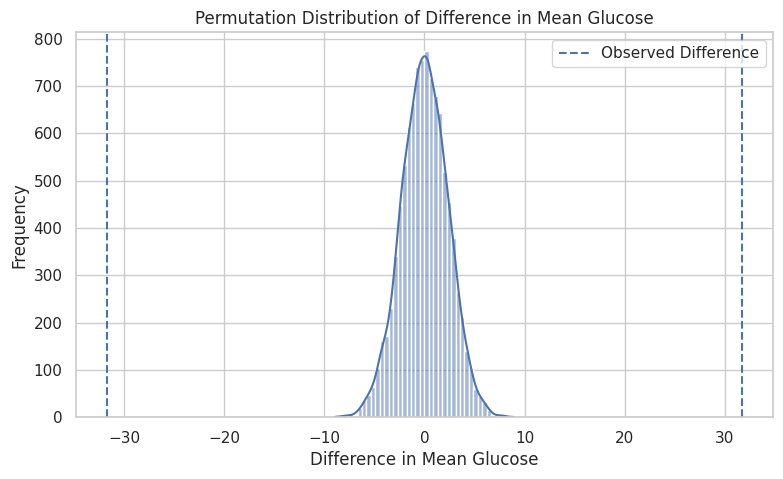

In [11]:
plt.figure(figsize=(9, 5))
sns.histplot(
    permuted_differences,
    bins=40,
    kde=True
)
plt.axvline(
    observed_difference,
    linestyle="--",
    label="Observed Difference"
)
plt.axvline(
    -abs(observed_difference),
    linestyle="--"
)
plt.title("Permutation Distribution of Difference in Mean Glucose")
plt.xlabel("Difference in Mean Glucose")
plt.ylabel("Frequency")
plt.legend()
plt.show()

## Conclusion

Bootstrap and permutation resampling techniques were implemented on the Pima Indians Diabetes Dataset. Bootstrap resampling was used to estimate the sampling distribution and a 95% confidence interval for mean Glucose. A permutation test was used to analyze the difference in mean Glucose between diabetic and non-diabetic groups. The permutation p-value was compared with the significance level of 0.05 to make the statistical decision.